In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import json
import logging
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from scipy.sparse import hstack

In [ ]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

In [ ]:
PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports" / "Module_3"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def load_data():
    logger.info("Loading training and testing data...")
    train_df = pd.read_csv(DATA_DIR / "train.csv")
    test_df = pd.read_csv(DATA_DIR / "test.csv")
    
    with open(ARTIFACTS_DIR / "feature_metadata.json", "r") as f:
        feature_metadata = json.load(f)
        
    tfidf_vectorizer = joblib.load(ARTIFACTS_DIR / "tfidf_vectorizer.pkl")
    label_encoder = joblib.load(ARTIFACTS_DIR / "label_encoder.pkl")
    
    return train_df, test_df, feature_metadata, tfidf_vectorizer, label_encoder

In [ ]:
def prepare_features(train_df, test_df, feature_metadata, tfidf_vectorizer):
    logger.info("Preparing features...")
    text_col = feature_metadata["text_column_for_tfidf"]
    num_cols = feature_metadata["numeric_feature_columns"]
    
    # TF-IDF Features
    # Fill NA just in case
    X_train_text = train_df[text_col].fillna("")
    X_test_text = test_df[text_col].fillna("")
    
    X_train_tfidf = tfidf_vectorizer.transform(X_train_text)
    X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
    
    # Numeric Features
    X_train_num = train_df[num_cols].fillna(0)
    X_test_num = test_df[num_cols].fillna(0)
    
    scaler = StandardScaler()
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_test_num_scaled = scaler.transform(X_test_num)
    
    # Save scaler for future use
    joblib.dump(scaler, ARTIFACTS_DIR / "scaler.pkl")
    
    # Combine Features
    X_train = hstack([X_train_num_scaled, X_train_tfidf]).tocsr()
    X_test = hstack([X_test_num_scaled, X_test_tfidf]).tocsr()
    
    y_train = train_df[feature_metadata["label_column_encoded"]]
    y_test = test_df[feature_metadata["label_column_encoded"]]
    
    return X_train, X_test, y_train, y_test

In [ ]:
def train_and_evaluate(X_train, X_test, y_train, y_test, class_names):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM": SVC(probability=True, random_state=42),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_estimators=50, max_depth=3, tree_method='hist')
    }
    
    results = []
    best_f1 = 0
    best_model_name = ""
    best_model = None
    best_y_pred = None
    best_y_proba = None
    
    for name, model in models.items():
        logger.info(f"Training {name}...")
        model.fit(X_train, y_train)
        
        logger.info(f"Evaluating {name}...")
        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
        else:
            y_proba = None
            
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision (Macro)": prec,
            "Recall (Macro)": rec,
            "F1 Score (Macro)": f1
        })
        
        if f1 > best_f1:
            best_f1 = f1
            best_model_name = name
            best_model = model
            best_y_pred = y_pred
            best_y_proba = y_proba
            
    results_df = pd.DataFrame(results)
    logger.info(f"Best Model: {best_model_name} with F1: {best_f1:.4f}")
    
    return results_df, best_model_name, best_model, best_y_pred, best_y_proba

In [ ]:
def generate_reports_and_visualizations(best_model_name, best_model, best_y_pred, best_y_proba, y_test, class_names, results_df):
    logger.info("Generating reports and visualizations...")
    
    # 1. Model Comparison CSV
    results_df.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
    
    # 2. Classification Report
    report_dict = classification_report(y_test, best_y_pred, labels=range(len(class_names)), target_names=class_names, output_dict=True, zero_division=0)
    report_str = classification_report(y_test, best_y_pred, labels=range(len(class_names)), target_names=class_names, zero_division=0)
    
    with open(REPORTS_DIR / "classification_report.md", "w") as f:
        f.write(f"# Classification Report (Best Model: {best_model_name})\n\n")
        f.write("```text\n")
        f.write(report_str)
        f.write("\n```\n")
        
    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, best_y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=300)
    plt.close()
    
    # 4. ROC Curves
    if best_y_proba is not None:
        y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
        n_classes = y_test_bin.shape[1]
        
        plt.figure(figsize=(10, 8))
        for i in range(min(n_classes, 10)): # Plot top 10 classes to avoid clutter
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{class_names[i][:15]} (AUC = {roc_auc:.2f})')
            
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curves - {best_model_name} (Top 10 Classes)')
        plt.legend(loc="lower right", fontsize='small', ncol=2)
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / "roc_curves.png", dpi=300)
        plt.close()

In [ ]:
def main():
    train_df, test_df, feature_metadata, tfidf_vectorizer, label_encoder = load_data()
    class_names = feature_metadata["class_names"]
    
    X_train, X_test, y_train, y_test = prepare_features(train_df, test_df, feature_metadata, tfidf_vectorizer)
    
    results_df, best_model_name, best_model, best_y_pred, best_y_proba = train_and_evaluate(
        X_train, X_test, y_train, y_test, class_names
    )
    
    generate_reports_and_visualizations(
        best_model_name, best_model, best_y_pred, best_y_proba, y_test, class_names, results_df
    )
    
    # Save the best model
    logger.info("Saving best model...")
    joblib.dump(best_model, ARTIFACTS_DIR / "best_model.pkl")
    
    logger.info("Module 3 Training Completed Successfully.")

In [ ]:
if __name__ == "__main__":
    main()

# Semantic Resume Matching

**Goal:** Use SentenceTransformers to generate embeddings for Resumes and Job Descriptions, and compute Cosine Similarity to find the best matching candidates.

## Why this module exists
Keyword matching (like TF-IDF) is limited because it cannot understand the context or semantic meaning of words (e.g. "Software Developer" vs "Programmer"). Semantic matching using embeddings solves this by mapping texts to dense vectors where similar meanings are closer in distance.

## How it integrates
It uses the cleaned data from# and builds a semantic search engine on top of it, creating the foundational mechanism for ranking candidates (# ) and the RAG pipeline (# ).

## Algorithms used
- **Sentence-BERT (SentenceTransformers)**: Specifically `all-MiniLM-L6-v2`, which is fast and provides excellent embeddings for semantic similarity tasks.
- **Cosine Similarity**: Measures the cosine of the angle between two multi-dimensional vectors (Job Description and Resume embeddings).

## Inputs & Outputs
- **Input**: Cleaned Resume Texts (`train.csv`), Job Descriptions.
- **Output**: Embeddings `.pkl` files, Similarity Reports (`.csv`, `.md`), Heatmap (`.png`).


In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

import torch
torch.set_num_threads(1)
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
from sentence_transformers import SentenceTransformer

## 1. Load the Model and Data

In [2]:
model_name = 'all-MiniLM-L6-v2'
print(f"Loading SentenceTransformer model {model_name}...")
model = SentenceTransformer(model_name)

Loading SentenceTransformer model all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
print("Loading train.csv resumes...")
try:
    df = pd.read_csv('../data/processed/train.csv').fillna("")
except FileNotFoundError:
    df = pd.read_csv('../data/processed/resumes_eda_pass.csv').fillna("")
    
print(f"Loaded {len(df)} resumes.")

Loading train.csv resumes...


Loaded 2589 resumes.


## 2. Generate Embeddings

In [4]:
print("Generating SentenceTransformer embeddings for resumes...")
if "clean_text" in df.columns:
    texts = df["clean_text"].tolist()
else:
    texts = df["Text"].tolist()

# Generate embeddings
embeddings = model.encode(texts, batch_size=8, show_progress_bar=True)

Generating SentenceTransformer embeddings for resumes...


Batches:   0%|          | 0/324 [00:00<?, ?it/s]

In [5]:
# Save embeddings
os.makedirs('../vector_store', exist_ok=True)
os.makedirs('../models', exist_ok=True)
joblib.dump(embeddings, '../vector_store/st_resume_embeddings.pkl')
joblib.dump(df["ResumeID"].tolist(), '../vector_store/st_resume_ids.pkl')

import json
with open('../models/embedding_model_info.json', 'w') as f:
    json.dump({"model_name": model_name, "type": "SentenceTransformer"}, f)
print("Embeddings saved!")

Embeddings saved!


## 3. Match Job Descriptions

In [6]:
jds = [
    "Looking for a Data Scientist with experience in Machine Learning, Python, Pandas, Scikit-Learn, and Deep Learning.",
    "Need a Backend Developer skilled in Node.js, Express, MongoDB, and RESTful APIs.",
    "Hiring a Cloud Engineer with AWS, Docker, Kubernetes, and Terraform experience."
]

jd_embeddings = model.encode(jds)
similarity_matrix = cosine_similarity(jd_embeddings, embeddings)

## 4. Visualizations and Reports

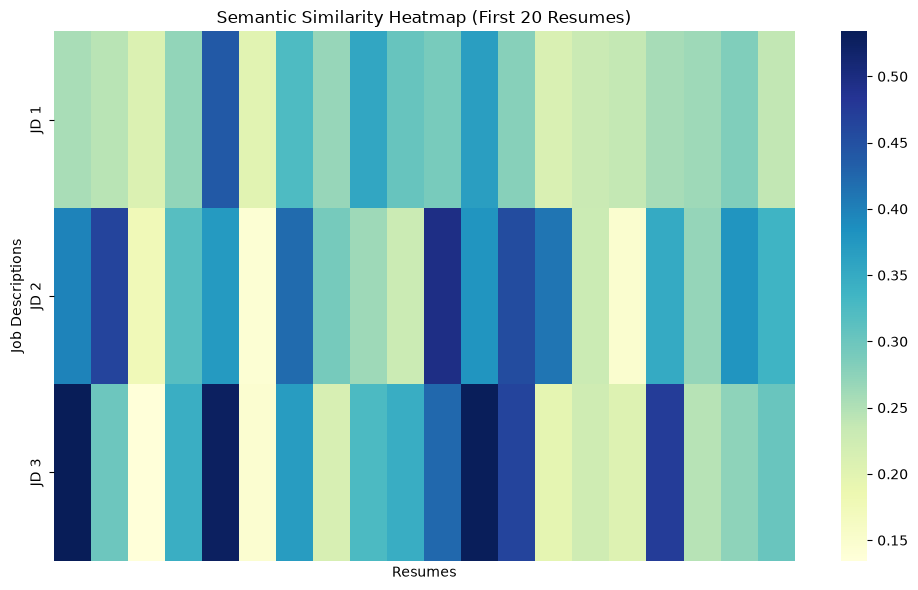

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(similarity_matrix[:, :20], cmap="YlGnBu", xticklabels=False, yticklabels=[f"JD {i+1}" for i in range(len(jds))])
plt.title("Semantic Similarity Heatmap (First 20 Resumes)")
plt.xlabel("Resumes")
plt.ylabel("Job Descriptions")
plt.tight_layout()
os.makedirs('../reports/Module_4', exist_ok=True)
plt.savefig('../reports/Module_4/similarity_heatmap.png')
plt.show()

In [8]:
all_results = []

for i, jd in enumerate(jds):
    cosine_scores = similarity_matrix[i]
    top_indices = cosine_scores.argsort()[-5:][::-1]
    
    results = []
    for idx in top_indices:
        score = cosine_scores[idx]
        resume_data = df.iloc[idx]
        results.append({
            "ResumeID": resume_data["ResumeID"],
            "Category": resume_data.get("Category", ""),
            "SimilarityScore": score,
            "Skills": resume_data.get("extracted_skills", resume_data.get("Skills", ""))
        })
    results_df = pd.DataFrame(results)
    results_df["JD_ID"] = f"JD_{i+1}"
    all_results.append(results_df)

final_results = pd.concat(all_results, ignore_index=True)
final_results.to_csv('../reports/Module_4/similarity_report.csv', index=False)
print("Saved similarity_report.csv")

Saved similarity_report.csv
